In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ZIP_DIR="/content/drive/MyDrive/EEG_Data"
# ZIP_NAME="Cal-Poly-EEG-Data-main.zip"
# OUT_DIR="/content/drive/MyDrive/EEG_Data"

# !mkdir -p "$OUT_DIR"
# !unzip -q -o "$ZIP_DIR/$ZIP_NAME" -d "$OUT_DIR"
# !ls -lah "$OUT_DIR"


total 967M
drwx------ 5 root root 4.0K Oct 13 05:11 Cal-Poly-EEG-Data-main
-rw------- 1 root root 967M Nov  6 17:33 Cal-Poly-EEG-Data-main.zip


In [ ]:
# import os
# import zipfile

# base_dir = '/content/drive/MyDrive/EEG_Data/Cal-Poly-EEG-Data-main/raw'

# for root, dirs, files in os.walk(base_dir):
#     for file in files:
#         if file.endswith('.zip'):
#             zip_path = os.path.join(root, file)
#             extract_path = root # Extract to the current directory
#             with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#                 zip_ref.extractall(extract_path)
#             print(f"Unzipped {zip_path} to {extract_path}")

Unzipped /content/drive/MyDrive/EEG_Data/Cal-Poly-EEG-Data-main/raw/1/control/67c26f8829d462ae823bb2c2.zip to /content/drive/MyDrive/EEG_Data/Cal-Poly-EEG-Data-main/raw/1/control
Unzipped /content/drive/MyDrive/EEG_Data/Cal-Poly-EEG-Data-main/raw/1/control/67c6544e496c87641bc32d1e.zip to /content/drive/MyDrive/EEG_Data/Cal-Poly-EEG-Data-main/raw/1/control
Unzipped /content/drive/MyDrive/EEG_Data/Cal-Poly-EEG-Data-main/raw/1/control/67c6621d2d2c5367115b87c6.zip to /content/drive/MyDrive/EEG_Data/Cal-Poly-EEG-Data-main/raw/1/control
Unzipped /content/drive/MyDrive/EEG_Data/Cal-Poly-EEG-Data-main/raw/1/control/67c66f62f0dce1020cccb8ba.zip to /content/drive/MyDrive/EEG_Data/Cal-Poly-EEG-Data-main/raw/1/control
Unzipped /content/drive/MyDrive/EEG_Data/Cal-Poly-EEG-Data-main/raw/1/control/67c77b63037bc8de9f8902ca.zip to /content/drive/MyDrive/EEG_Data/Cal-Poly-EEG-Data-main/raw/1/control
Unzipped /content/drive/MyDrive/EEG_Data/Cal-Poly-EEG-Data-main/raw/1/control/67c77fa5037bc8de9f890800.zi

In [ ]:
import os
import glob
import pandas as pd

# --- Configuration ---
data_root = '/content/drive/MyDrive/EEG_Data/Cal-Poly-EEG-Data-main/raw/2'         # Change to 'OrganizedRSCA/2' for study 2
output_root = 'MergedRSCA'            # Output directory for merged data
MERGE_ALL = False                      # <<< Toggle: True for full merge only, False for group-by-group

# --- Define question groups by index range ---
question_groups = {
    'Belong1': range(1, 5),
    'Belong2': range(5, 9),
    'Belong3': range(9, 13),
    'Belong4': range(13, 18),
    'Belong5': range(18, 24),
    'Course': range(24, 34),
    'Parsons': range(34, 40),
    'Demo': range(40, 47),
    'Feedback': range(47, 52)
}

# --- Main Loop: Process Each Study Folder ---
for study_folder in os.listdir(data_root):
    study_path = os.path.join(data_root, study_folder)
    out_study_path = os.path.join(output_root, study_folder)

    if not os.path.isdir(study_path): # Added check here
        continue

    for person_folder in os.listdir(study_path):
        person_path = os.path.join(study_path, person_folder)

        if not os.path.isdir(person_path):
            continue

        csv_files = sorted(glob.glob(os.path.join(person_path, '*.csv')))
        file_map = {}

        for file in csv_files:
            parts = os.path.basename(file).split('_')
            if len(parts) >= 4:
                try:
                    seq_num = int(parts[2])  # Assumes format like: PREFIX_<ID>_<QNUM>_SUFFIX.csv
                    file_map[seq_num] = file
                except ValueError:
                    continue

        person_id = os.path.basename(person_path)
        merged_out_dir = os.path.join(out_study_path, person_id)
        os.makedirs(merged_out_dir, exist_ok=True)

        if MERGE_ALL:
            # --- Merge all files into one, skip group merging ---
            all_dataframes = []
            # Sort file_map by key (sequence number) before processing
            for seq_num in sorted(file_map.keys()):
                file = file_map[seq_num]
                df = pd.read_csv(file)
                all_dataframes.append(df)

            if all_dataframes:
                full_merged = pd.concat(all_dataframes, ignore_index=True)
                full_merged.dropna(inplace=True)

                full_merged_path = os.path.join(merged_out_dir, f"{person_id}_all.csv")
                full_merged.to_csv(full_merged_path, index=False)
                print(f"Saved merged all file: {full_merged_path}")
        else:
            # --- Group-by-group merge ---
            all_missing = {}

            for group_name, questions in question_groups.items():
                missing = []
                dataframes = []

                # Sort question numbers before processing
                for q_num in sorted(questions):
                    if q_num not in file_map:
                        missing.append(q_num)
                    else:
                        df = pd.read_csv(file_map[q_num])
                        dataframes.append(df)

                if missing:
                    all_missing[group_name] = missing
                    print(f"Skipped {group_name} for {person_id} due to missing files: {missing}")
                    continue

                if dataframes:
                    merged_df = pd.concat(dataframes, ignore_index=True)
                    merged_df.dropna(inplace=True)

                    merged_path = os.path.join(merged_out_dir, f"{person_id}_{group_name}.csv")
                    merged_df.to_csv(merged_path, index=False)
                    print(f"Saved merged file: {merged_path}")

            # --- Save missing summary ---
            if all_missing:
                missing_path = os.path.join(merged_out_dir, f"{person_id}_missing_questions.txt")
                with open(missing_path, 'w') as f:
                    for group, missing_list in all_missing.items():
                        f.write(f"{group}: missing question numbers {missing_list}\n")

Skipped Belong1 for 67c2836837717e8573ee0670 due to missing files: [1, 2, 3, 4]
Skipped Belong2 for 67c2836837717e8573ee0670 due to missing files: [5, 6, 7, 8]
Skipped Belong3 for 67c2836837717e8573ee0670 due to missing files: [9, 10, 11, 12]
Skipped Belong4 for 67c2836837717e8573ee0670 due to missing files: [13, 14, 15, 16, 17]
Skipped Belong5 for 67c2836837717e8573ee0670 due to missing files: [18, 19, 20, 21, 22, 23]
Skipped Course for 67c2836837717e8573ee0670 due to missing files: [24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Skipped Parsons for 67c2836837717e8573ee0670 due to missing files: [34, 35, 36, 37, 38, 39]
Skipped Demo for 67c2836837717e8573ee0670 due to missing files: [40, 41, 42, 43, 44, 45, 46]
Skipped Feedback for 67c2836837717e8573ee0670 due to missing files: [47, 48, 49, 50, 51]
Saved merged file: MergedRSCA/growth/67c6688bf0dce1020cccb08b/67c6688bf0dce1020cccb08b_Belong1.csv
Saved merged file: MergedRSCA/growth/67c6688bf0dce1020cccb08b/67c6688bf0dce1020cccb08b_Belong2.cs

# Scalogram


## initial

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
csv_path = "/content/MergedRSCA/control/67d0a48d0b0cf28d843388f3/67d0a48d0b0cf28d843388f3_all.csv"

In [ ]:
df = pd.read_csv(csv_path)
df

,Timestamp,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5
0,1.741727e+09,-13.183594,-72.265625,-136.718750,-19.531250,-148.925781
1,1.741727e+09,-53.710938,-381.347656,-318.847656,-277.343750,-77.636719
2,1.741727e+09,-24.902344,-243.164062,-140.136719,666.992188,-99.121094
3,1.741727e+09,-25.878906,-188.476562,-130.859375,999.511719,-104.980469
4,1.741727e+09,-42.968750,-417.480469,-296.875000,344.726562,-54.687500
...,...,...,...,...,...,...
213036,1.741727e+09,-10.253906,-407.714844,-245.605469,-749.023438,39.550781
213037,1.741727e+09,1.953125,-447.753906,-250.488281,-615.722656,-8.789062
213038,1.741727e+09,9.277344,-119.628906,-65.917969,577.148438,-63.964844
213039,1.741727e+09,17.089844,-146.484375,-123.535156,662.109375,7.324219


In [ ]:
df["Timestamp"].iloc[0], df["Timestamp"].iloc[-1], df["Timestamp"].iloc[0] == df["Timestamp"].iloc[-1]

(np.float64(1741726996.611125), np.float64(1741726969.977281), np.False_)

In [ ]:
df["Timestamp"].iloc[-1] - df["Timestamp"].iloc[5000]

np.float64(-246.96090650558472)

In [ ]:
df["Timestamp"].is_monotonic_increasing

False

In [ ]:
df_sorted = df.sort_values("Timestamp").reset_index(drop=True)
df_sorted

,Timestamp,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5
0,1.741727e+09,-145.019531,-469.238281,-360.351562,-1000.000000,-114.257812
1,1.741727e+09,-129.394531,-177.246094,-222.167969,-730.957031,-212.890625
2,1.741727e+09,-101.562500,-55.175781,-216.796875,57.617188,-195.312500
3,1.741727e+09,-99.609375,-361.328125,-328.613281,-270.507812,-94.726562
4,1.741727e+09,-134.277344,-656.250000,-374.023438,-1000.000000,26.367188
...,...,...,...,...,...,...
213036,1.741728e+09,-31.250000,238.769531,2.441406,363.769531,-172.851562
213037,1.741728e+09,-27.832031,114.746094,-25.390625,106.933594,-73.242188
213038,1.741728e+09,-21.972656,164.062500,-29.785156,-723.144531,-183.593750
213039,1.741728e+09,-42.480469,73.730469,-43.457031,-477.050781,-170.898438


In [ ]:
df_sorted["Timestamp"].is_monotonic_increasing

True

In [ ]:
df_sorted["Timestamp"].iloc[-1] - df_sorted["Timestamp"].iloc[5000]

np.float64(946.9341876506805)

In [ ]:
pd.set_option('display.max_rows', 100)
df["Timestamp"].value_counts()

,count
Timestamp,
1.740797e+09,160
1.740797e+09,160
1.740797e+09,160
1.740797e+09,160
1.740797e+09,160
...,...
1.740796e+09,1
1.740796e+09,1
1.740796e+09,1


In [ ]:
df.columns

Index(['Timestamp', 'Channel 1', 'Channel 2', 'Channel 3', 'Channel 4',
       'Channel 5'],
      dtype='object')

In [ ]:
df = df_sorted.copy()
df

,Timestamp,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5
0,1.741727e+09,-145.019531,-469.238281,-360.351562,-1000.000000,-114.257812
1,1.741727e+09,-129.394531,-177.246094,-222.167969,-730.957031,-212.890625
2,1.741727e+09,-101.562500,-55.175781,-216.796875,57.617188,-195.312500
3,1.741727e+09,-99.609375,-361.328125,-328.613281,-270.507812,-94.726562
4,1.741727e+09,-134.277344,-656.250000,-374.023438,-1000.000000,26.367188
...,...,...,...,...,...,...
213036,1.741728e+09,-31.250000,238.769531,2.441406,363.769531,-172.851562
213037,1.741728e+09,-27.832031,114.746094,-25.390625,106.933594,-73.242188
213038,1.741728e+09,-21.972656,164.062500,-29.785156,-723.144531,-183.593750
213039,1.741728e+09,-42.480469,73.730469,-43.457031,-477.050781,-170.898438


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import detrend

# Channel 1 - 4
channel_name = "Channel 2"

# signal & "time" (row index)
sig = np.asarray(df[channel_name], dtype=float).reshape(-1)
t = np.arange(sig.size) # each row in the csv is separated by 1 unit

fs = 256 # 256 bc muse uses this
fmin, fmax, num_freqs = 4.0, 10.0, 60            # Hz
target_freqs = np.geomspace(fmin, fmax, num_freqs)

central = pywt.central_frequency("morl")
scales  = central * fs / target_freqs

coeffs, freqs = pywt.cwt(sig, scales, "morl", sampling_period=1/fs)  # freqs in Hz
t = np.arange(sig.size) / fs


# plooting code
plt.figure(figsize=(10, 5))
plt.pcolormesh(t, freqs, power, shading="auto")
plt.xlabel("Time (rows)")
plt.ylabel("Frequency (HZ)")
plt.title(f"Scalogram — {channel_name}")
plt.colorbar(label="Power")
plt.tight_layout()
plt.show()


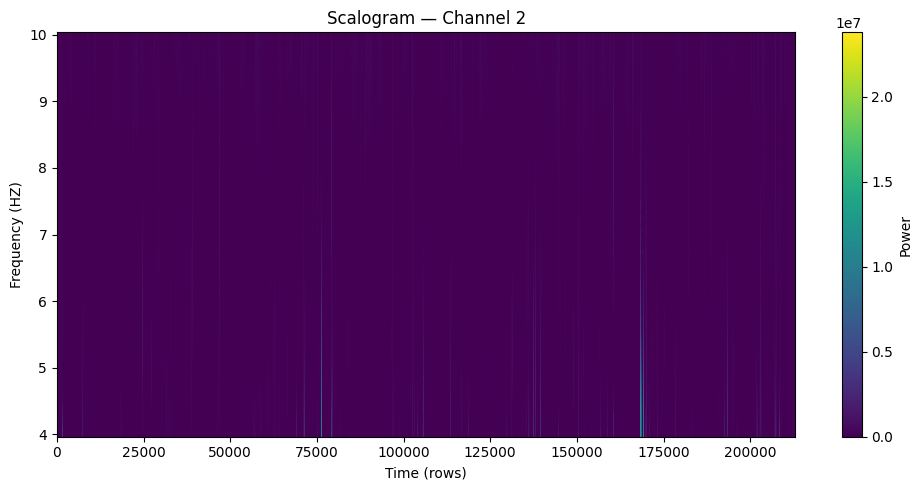

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import detrend

# Channel 1 - 4
channel_name = "Channel 2"

# 1) signal & "time" (row index)
sig = np.asarray(df[channel_name], dtype=float).reshape(-1)
t = np.arange(sig.size) # each row in the csv is separated by 1 unit
fs = 256 # Muse 2 headhand is 256Hz Sampling Freq
sig = detrend(sig, type="linear")  # may remove, this is a way to remove linear drift from signal


fmin, fmax, num_freqs = 4, 10, 80   # in HZ, min and max kinda like a filter
target_freqs = np.linspace(fmin, fmax, num_freqs)
central = pywt.central_frequency("morl")
scales = central * fs / target_freqs

#CWT MORL transformation
coeffs, freqs = pywt.cwt(sig, scales, "morl", sampling_period=1/fs)  # freqs in cycles/unit
power = np.abs(coeffs)**2

# plooting code
plt.figure(figsize=(10, 5))
plt.pcolormesh(t, freqs, power, shading="auto")
plt.xlabel("Time (rows)")
plt.ylabel("Frequency (HZ)")
plt.title(f"Scalogram — {channel_name}")
plt.colorbar(label="Power")
plt.tight_layout()
plt.show()


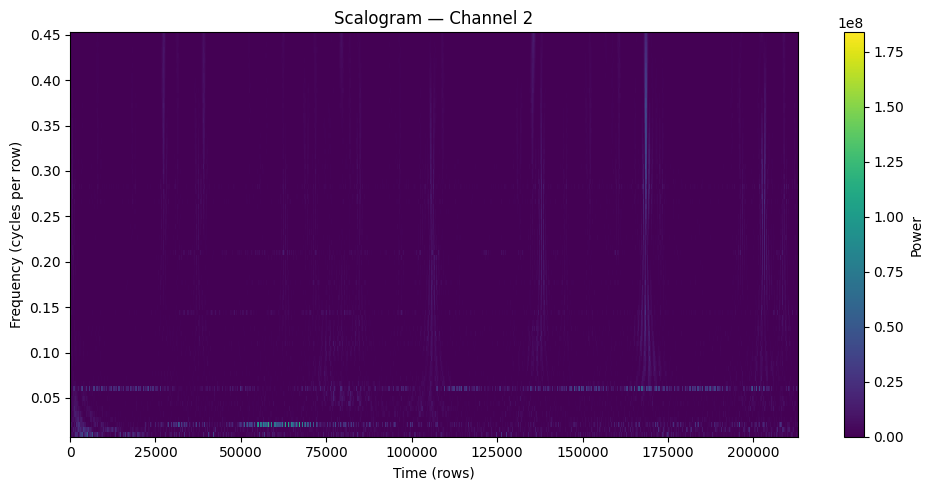

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import detrend

# Channel 1 - 4
channel_name = "Channel 2"


sig = np.asarray(df[channel_name], dtype=float).reshape(-1)
t = np.arange(sig.size) # each row in the csv is separated by 1 unit
fs = 256 # Muse 2 headhand is 256Hz Sampling Freq
sig = detrend(sig, type="linear")  # may remove, this is a way to remove linear drift from signal


fmin, fmax, num_freqs = 0.01, 0.45, 80   # in HZ, min and max kinda like a filter
target_freqs = np.linspace(fmin, fmax, num_freqs)
central = pywt.central_frequency("morl")
scales = central * fs / target_freqs

#CWT MORL transformation
coeffs, freqs = pywt.cwt(sig, scales, "morl", sampling_period=1/fs)  # freqs in cycles/unit
power = np.abs(coeffs)**2

# plooting code
plt.figure(figsize=(10, 5))
plt.pcolormesh(t, freqs, power, shading="auto")
plt.xlabel("Time (rows)")
plt.ylabel("Frequency (cycles per row)")
plt.title(f"Scalogram — {channel_name}")
plt.colorbar(label="Power")
plt.tight_layout()
plt.show()


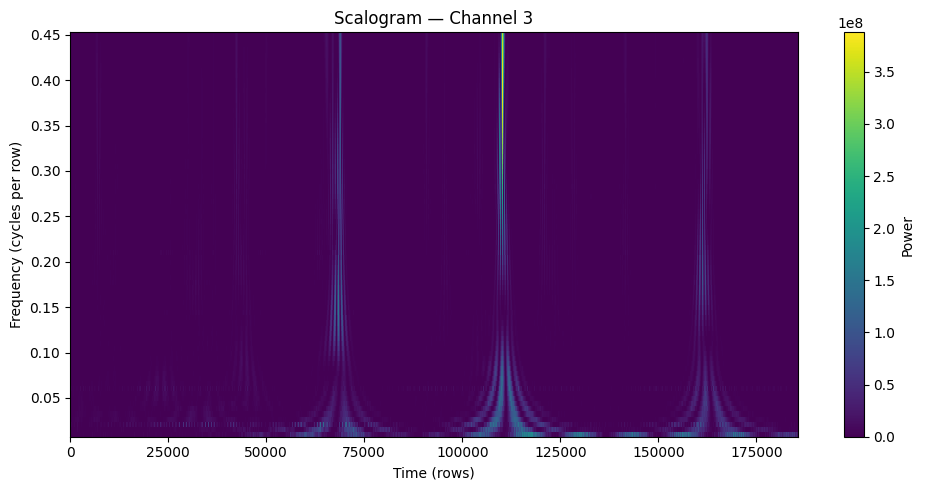

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import detrend

channel_name = "Channel 3"

sig = np.asarray(df[channel_name], dtype=float).reshape(-1)
t = np.arange(sig.size)
fs = 256
sig = detrend(sig, type="linear")


fmin, fmax, num_freqs = 0.01, 0.45, 80
target_freqs = np.linspace(fmin, fmax, num_freqs)
central = pywt.central_frequency("morl")
scales = central * fs / target_freqs

coeffs, freqs = pywt.cwt(sig, scales, "morl", sampling_period=1/fs)
power = np.abs(coeffs)**2

plt.figure(figsize=(10, 5))
plt.pcolormesh(t, freqs, power, shading="auto")
plt.xlabel("Time (rows)")
plt.ylabel("Frequency (cycles per row)")
plt.title(f"Scalogram — {channel_name}")
plt.colorbar(label="Power")
plt.tight_layout()
plt.show()


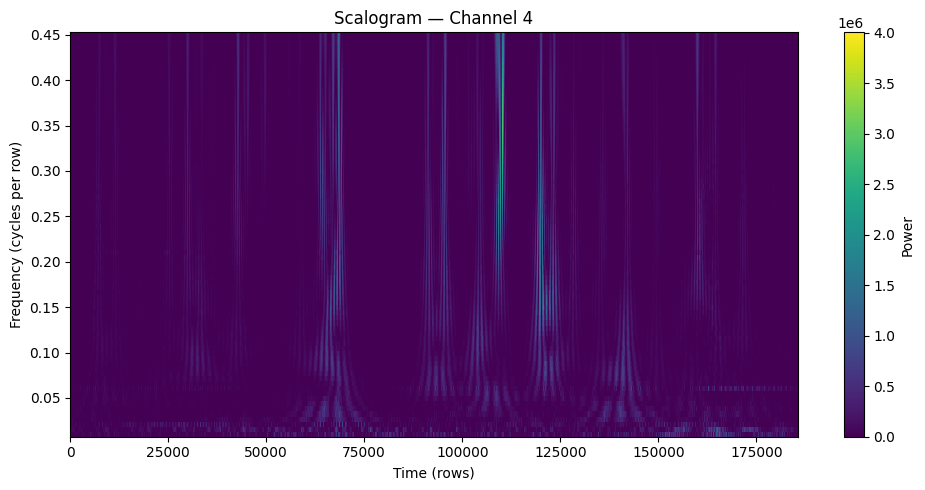

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import detrend

channel_name = "Channel 4"

sig = np.asarray(df[channel_name], dtype=float).reshape(-1)
t = np.arange(sig.size)
fs = 256
sig = detrend(sig, type="linear")


fmin, fmax, num_freqs = 0.01, 0.45, 80
target_freqs = np.linspace(fmin, fmax, num_freqs)
central = pywt.central_frequency("morl")
scales = central * fs / target_freqs

coeffs, freqs = pywt.cwt(sig, scales, "morl", sampling_period=1/fs)
power = np.abs(coeffs)**2

plt.figure(figsize=(10, 5))
plt.pcolormesh(t, freqs, power, shading="auto")
plt.xlabel("Time (rows)")
plt.ylabel("Frequency (cycles per row)")
plt.title(f"Scalogram — {channel_name}")
plt.colorbar(label="Power")
plt.tight_layout()
plt.show()


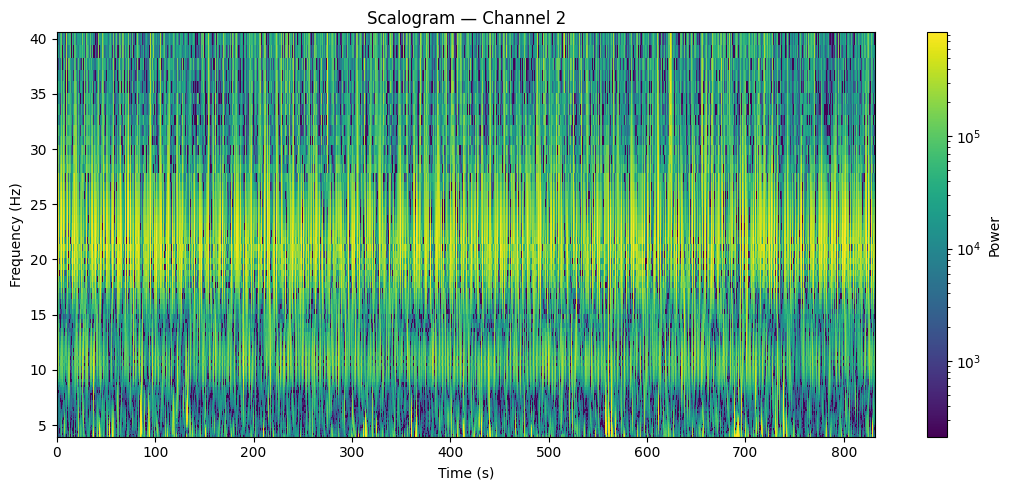

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import detrend
from matplotlib.colors import LogNorm

channel_name = "Channel 2"
fs = 256                    # Hz (Muse 2)
fmin, fmax = 4.0, 40
num_freqs = 80

sig = np.asarray(df[channel_name], dtype=float).reshape(-1)
sig = detrend(sig, type="linear")
t_sec = np.arange(sig.size) / fs

target_freqs = np.geomspace(fmin, fmax, num_freqs) # log spacing is nicer to read for EEG
central = pywt.central_frequency("morl")
scales = central * fs / target_freqs

coeffs, freqs = pywt.cwt(sig, scales, "morl", sampling_period=1/fs)
power = np.abs(coeffs) ** 2

# to make sure not one part overshadows like b4
vmin = np.nanpercentile(power, 5)
vmax = np.nanpercentile(power, 99)

plt.figure(figsize=(11, 5))
plt.pcolormesh(t_sec, freqs, power, shading="auto",
               norm=LogNorm(vmin=max(vmin, 1e-12), vmax=vmax))
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"Scalogram — {channel_name}")
plt.colorbar(label="Power")
plt.tight_layout()
plt.show()


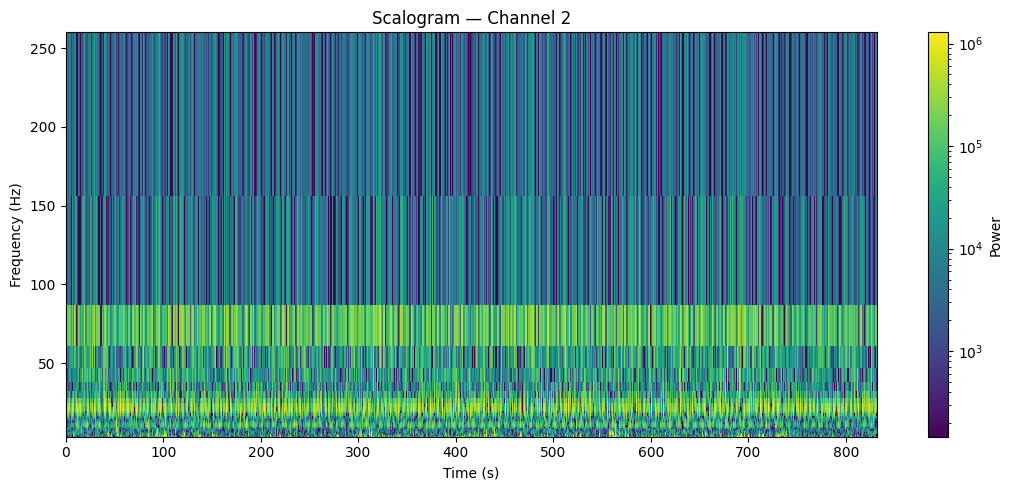

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import detrend
from matplotlib.colors import LogNorm

channel_name = "Channel 2"
fs = 256                    # Hz (Muse 2)
fmin, fmax = 4.0, 40
num_freqs = 80

sig = np.asarray(df[channel_name], dtype=float).reshape(-1)
sig = detrend(sig, type="linear")
t_sec = np.arange(sig.size) / fs

# target_freqs = np.geomspace(fmin, fmax, num_freqs) # log spacing is nicer to read for EEG
# central = pywt.central_frequency("morl")
# scales = central * fs / target_freqs

coeffs, freqs = pywt.cwt(sig, scales = range(1,65), wavelet = "morl", sampling_period=1/fs)
power = np.abs(coeffs) ** 2

# to make sure not one part overshadows like b4
vmin = np.nanpercentile(power, 5)
vmax = np.nanpercentile(power, 99)

plt.figure(figsize=(11, 5))
plt.pcolormesh(t_sec, freqs, power, shading="auto",
               norm=LogNorm(vmin=max(vmin, 1e-12), vmax=vmax))
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"Scalogram — {channel_name}")
plt.colorbar(label="Power")
plt.tight_layout()
plt.show()

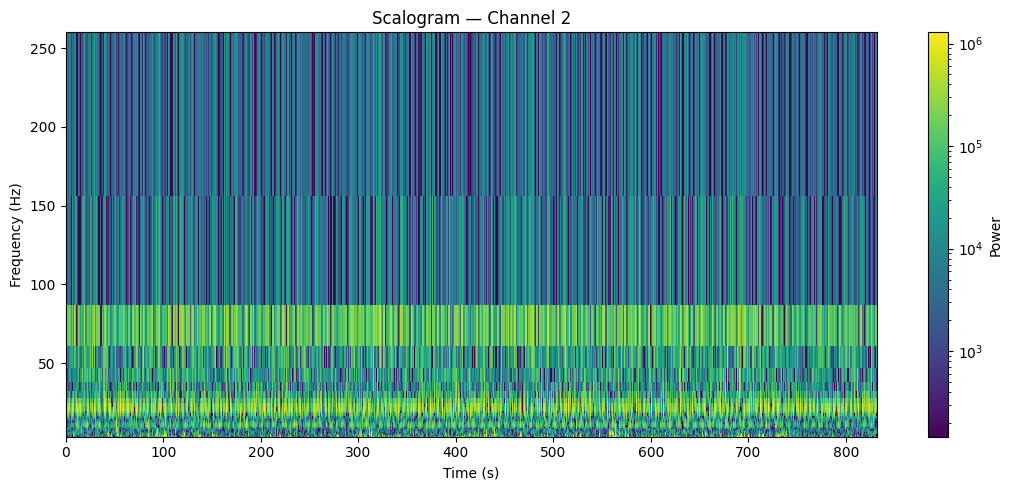

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import detrend
from matplotlib.colors import LogNorm

channel_name = "Channel 2"
fs = 256                    # Hz (Muse 2)
fmin, fmax = 4.0, 8
num_freqs = 80

sig = np.asarray(df[channel_name], dtype=float).reshape(-1)
sig = detrend(sig, type="linear")
t_sec = np.arange(sig.size) / fs


# target_freqs = np.geomspace(fmin, fmax, num_freqs) # log spacing is nicer to read for EEG
# central = pywt.central_frequency("morl")
# scales = central * fs / target_freqs

coeffs, freqs = pywt.cwt(sig, scales = range(1,65), wavelet = "morl", sampling_period=1/fs)
power = np.abs(coeffs) ** 2

# to make sure not one part overshadows like b4
vmin = np.nanpercentile(power, 5)
vmax = np.nanpercentile(power, 99)

plt.figure(figsize=(11, 5))
plt.pcolormesh(t_sec, freqs, power, shading="auto",
               norm=LogNorm(vmin=max(vmin, 1e-12), vmax=vmax))
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"Scalogram — {channel_name}")
plt.colorbar(label="Power")
plt.tight_layout()
plt.show()


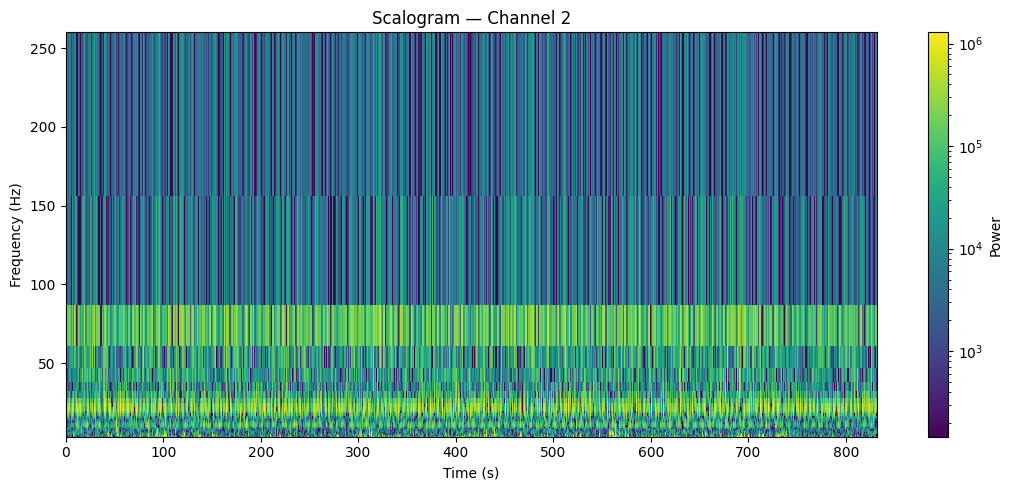

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import detrend
from matplotlib.colors import LogNorm

channel_name = "Channel 2"
fs = 256                    # Hz (Muse 2)
fmin, fmax = 8, 12
num_freqs = 80

sig = np.asarray(df[channel_name], dtype=float).reshape(-1)
sig = detrend(sig, type="linear")
t_sec = np.arange(sig.size) / fs


# target_freqs = np.geomspace(fmin, fmax, num_freqs) # log spacing is nicer to read for EEG
# central = pywt.central_frequency("morl")
# scales = central * fs / target_freqs

coeffs, freqs = pywt.cwt(sig, scales = range(1,65), wavelet = "morl", sampling_period=1/fs)
power = np.abs(coeffs) ** 2

# to make sure not one part overshadows like b4
vmin = np.nanpercentile(power, 5)
vmax = np.nanpercentile(power, 99)

plt.figure(figsize=(11, 5))
plt.pcolormesh(t_sec, freqs, power, shading="auto",
               norm=LogNorm(vmin=max(vmin, 1e-12), vmax=vmax))
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"Scalogram — {channel_name}")
plt.colorbar(label="Power")
plt.tight_layout()
plt.show()

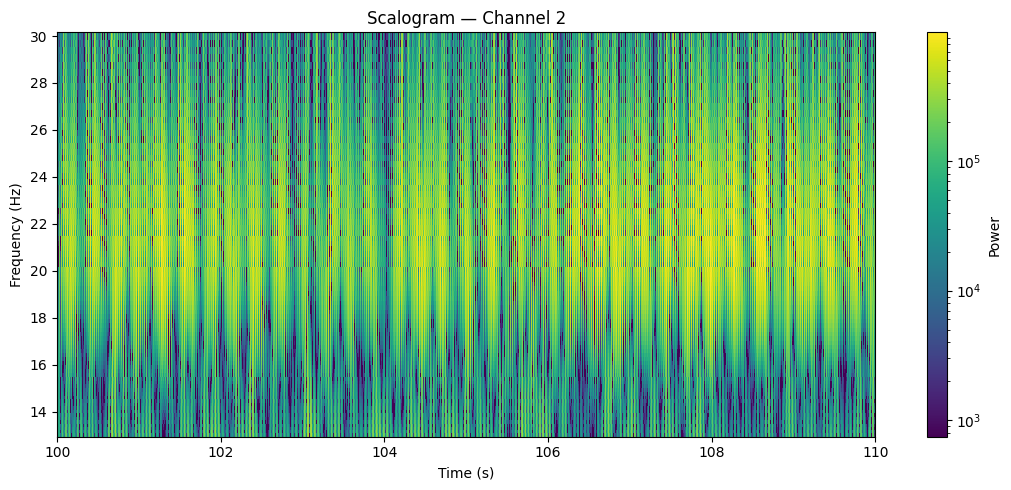

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import detrend
from matplotlib.colors import LogNorm

channel_name = "Channel 2"
fs = 256                    # Hz (Muse 2)
fmin, fmax = 13, 30
num_freqs = 80

sig = np.asarray(df[channel_name], dtype=float).reshape(-1)
sig = detrend(sig, type="linear")
t_sec = np.arange(sig.size) / fs

mask = (t_sec >= 100) & (t_sec <= 110)
sig = sig[mask]
t_sec = t_sec[mask]


target_freqs = np.geomspace(fmin, fmax, num_freqs) # log spacing is nicer to read for EEG
central = pywt.central_frequency("morl")
scales = central * fs / target_freqs

coeffs, freqs = pywt.cwt(sig, scales = scales, wavelet = "morl", sampling_period=1/fs)
power = np.abs(coeffs) ** 2

# to make sure not one part overshadows like b4
vmin = np.nanpercentile(power, 5)
vmax = np.nanpercentile(power, 99)

plt.figure(figsize=(11, 5))
plt.pcolormesh(t_sec, freqs, power, shading="auto"
,
               norm=LogNorm(vmin=max(vmin, 1e-12), vmax=vmax)
               )
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"Scalogram — {channel_name}")
plt.colorbar(label="Power")
plt.tight_layout()
plt.show()

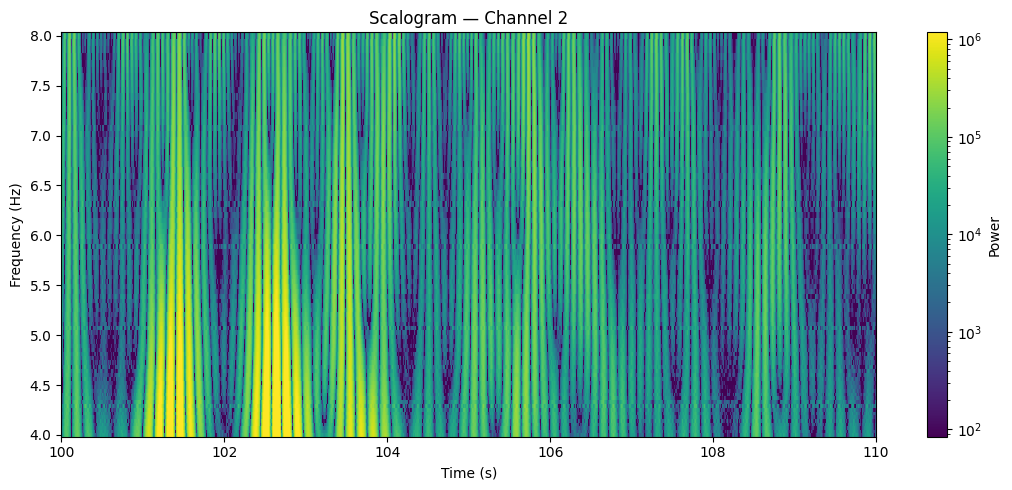

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import detrend
from matplotlib.colors import LogNorm

channel_name = "Channel 2"
fs = 256                    # Hz (Muse 2)
fmin, fmax = 4, 8
num_freqs = 80

sig = np.asarray(df[channel_name], dtype=float).reshape(-1)
sig = detrend(sig, type="linear")
t_sec = np.arange(sig.size) / fs

mask = (t_sec >= 100) & (t_sec <= 110)
sig = sig[mask]
t_sec = t_sec[mask]


target_freqs = np.geomspace(fmin, fmax, num_freqs) # log spacing is nicer to read for EEG
central = pywt.central_frequency("morl")
scales = central * fs / target_freqs

coeffs, freqs = pywt.cwt(sig, scales = scales, wavelet = "morl", sampling_period=1/fs)
power = np.abs(coeffs) ** 2

# to make sure not one part overshadows like b4
vmin = np.nanpercentile(power, 5)
vmax = np.nanpercentile(power, 99)

plt.figure(figsize=(11, 5))
plt.pcolormesh(t_sec, freqs, power, shading="auto"
,
               norm=LogNorm(vmin=max(vmin, 1e-12), vmax=vmax)
               )
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"Scalogram — {channel_name}")
plt.colorbar(label="Power")
plt.tight_layout()
plt.show()

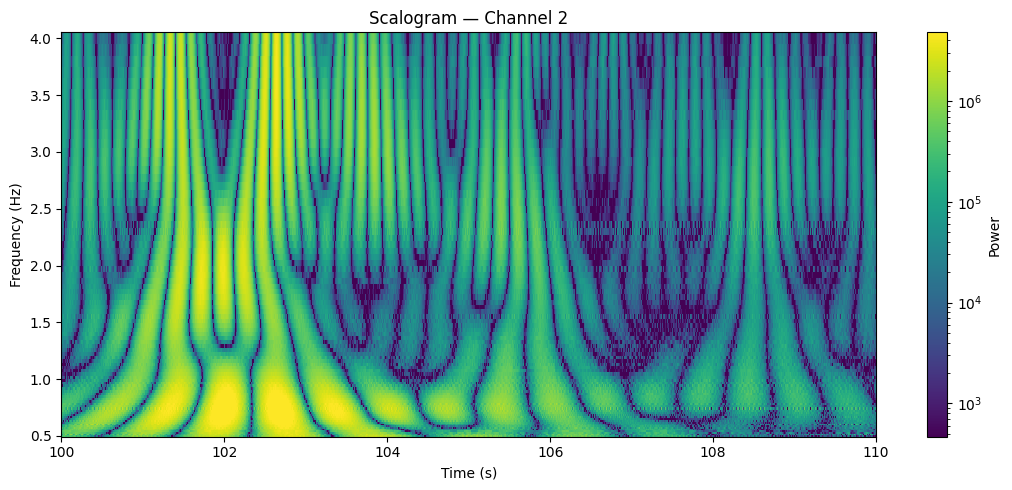

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import detrend
from matplotlib.colors import LogNorm

channel_name = "Channel 2"
fs = 256                    # Hz (Muse 2)
fmin, fmax = .5, 4
num_freqs = 80

sig = np.asarray(df[channel_name], dtype=float).reshape(-1)
sig = detrend(sig, type="linear")
t_sec = np.arange(sig.size) / fs

mask = (t_sec >= 100) & (t_sec <= 110)
sig = sig[mask]
t_sec = t_sec[mask]


target_freqs = np.geomspace(fmin, fmax, num_freqs) # log spacing is nicer to read for EEG
central = pywt.central_frequency("morl")
scales = central * fs / target_freqs

coeffs, freqs = pywt.cwt(sig, scales = scales, wavelet = "morl", sampling_period=1/fs)
power = np.abs(coeffs) ** 2

# to make sure not one part overshadows like b4
vmin = np.nanpercentile(power, 5)
vmax = np.nanpercentile(power, 99)

plt.figure(figsize=(11, 5))
plt.pcolormesh(t_sec, freqs, power, shading="auto"
,
               norm=LogNorm(vmin=max(vmin, 1e-12), vmax=vmax)
               )
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"Scalogram — {channel_name}")
plt.colorbar(label="Power")
plt.tight_layout()
plt.show()

## Question 1-4

In [ ]:
csv = '/content/MergedRSCA/growth/67c6688bf0dce1020cccb08b/67c6688bf0dce1020cccb08b_Belong1.csv'

In [ ]:
df1 = pd.read_csv(csv)
df1

,Timestamp,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5
0,1.741056e+09,-21.972656,4.882812,-7.812500,-38.085938,-192.871094
1,1.741056e+09,-23.437500,8.300781,-3.906250,-23.925781,-238.281250
2,1.741056e+09,-24.902344,-1.464844,-16.601562,-4.394531,-192.382812
3,1.741056e+09,-3.906250,1.464844,-25.390625,-0.976562,-104.492188
4,1.741056e+09,0.488281,0.488281,-28.320312,7.324219,-51.269531
...,...,...,...,...,...,...
10116,1.741056e+09,-10.253906,-34.179688,-41.992188,-14.160156,96.191406
10117,1.741056e+09,-8.300781,-25.390625,-38.574219,-26.855469,-83.984375
10118,1.741056e+09,-3.417969,-7.324219,-33.691406,-6.835938,-47.363281
10119,1.741056e+09,9.277344,-16.601562,-37.109375,-18.066406,211.914062


In [ ]:
df1["Timestamp"].is_monotonic_increasing

False

In [ ]:
df1_sorted = df1.sort_values("Timestamp").reset_index(drop=True)
df1_sorted

,Timestamp,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5
0,1.741056e+09,-21.972656,4.882812,-7.812500,-38.085938,-192.871094
1,1.741056e+09,-23.437500,8.300781,-3.906250,-23.925781,-238.281250
2,1.741056e+09,-24.902344,-1.464844,-16.601562,-4.394531,-192.382812
3,1.741056e+09,-3.906250,1.464844,-25.390625,-0.976562,-104.492188
4,1.741056e+09,0.488281,0.488281,-28.320312,7.324219,-51.269531
...,...,...,...,...,...,...
10116,1.741056e+09,-10.253906,-34.179688,-41.992188,-14.160156,96.191406
10117,1.741056e+09,-8.300781,-25.390625,-38.574219,-26.855469,-83.984375
10118,1.741056e+09,-3.417969,-7.324219,-33.691406,-6.835938,-47.363281
10119,1.741056e+09,9.277344,-16.601562,-37.109375,-18.066406,211.914062


In [ ]:
df1_sorted["Timestamp"].is_monotonic_increasing

True

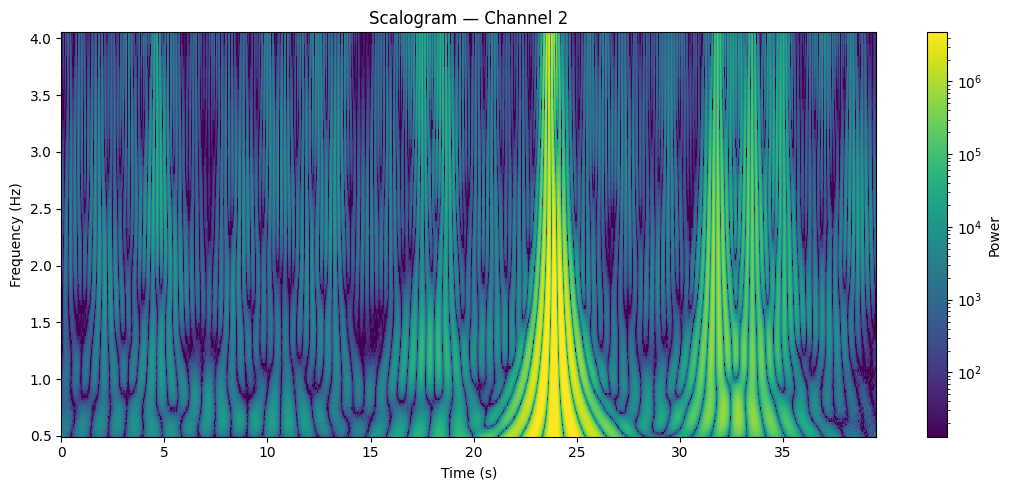

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import detrend
from matplotlib.colors import LogNorm

channel_name = "Channel 2"
fs = 256                    # Hz (Muse 2)
fmin, fmax = .5, 4
num_freqs = 80

sig = np.asarray(df1_sorted[channel_name], dtype=float).reshape(-1)
sig = detrend(sig, type="linear")
t_sec = np.arange(sig.size) / fs

# mask = (t_sec >= 100) & (t_sec <= 110)
# sig = sig[mask]
# t_sec = t_sec[mask]


target_freqs = np.geomspace(fmin, fmax, num_freqs) # log spacing is nicer to read for EEG
central = pywt.central_frequency("morl")
scales = central * fs / target_freqs

coeffs, freqs = pywt.cwt(sig, scales = scales, wavelet = "morl", sampling_period=1/fs)
power = np.abs(coeffs) ** 2

# to make sure not one part overshadows like b4
vmin = np.nanpercentile(power, 5)
vmax = np.nanpercentile(power, 99)

plt.figure(figsize=(11, 5))
plt.pcolormesh(t_sec, freqs, power, shading="auto"
,
               norm=LogNorm(vmin=max(vmin, 1e-12), vmax=vmax)
               )
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"Scalogram — {channel_name}")
plt.colorbar(label="Power")
plt.tight_layout()
plt.show()

# Scalograms


In mass, specify a channel and this will produce Scalograms for that channel. Currently set so that strid is 32 or 50% overlap with last sample. window is 64 and the data is sampled at 256 Hz bc thats what Muse 2 does. Currently looks at 4 to 40 Hz range

In [ ]:
import numpy as np
import pywt
from scipy.signal import detrend
from PIL import Image
import os
import matplotlib.cm as cm

# This function basically takes in the eeg signal, the specified window_size and stride and returns an
# array that has the various windows
def window_signal(sig, window_size, stride):
    starts = np.arange(0, max(len(sig) - window_size + 1, 0), stride)
    return np.stack([sig[s:s+window_size] for s in starts], axis=0) if len(starts) else np.empty((0, window_size))
    # Just a total windows by window size array of eeg values (n_windows, window_size)

def cwt_tile(signal_1d, fs, fmin=4, fmax=40, num_freqs=64, log_power=True):
    signal_1d = detrend(signal_1d, type="linear") # gets rid of linear drift (not sure if helpful especially since its per window)

    target_freqs = np.geomspace(fmin, fmax, num_freqs) # num_freqs from fmin to fmax. E.G. 64 freqs between 4 to 40 Hz
    central = pywt.central_frequency("morl")
    scales = central * fs / target_freqs # maps freq to CWT scales for Morlet

    coeffs, freqs = pywt.cwt(signal_1d, scales=scales, wavelet="morl", sampling_period=1/fs)
    power = (coeffs.real**2 + coeffs.imag**2) if np.iscomplexobj(coeffs) else np.abs(coeffs)**2

    # for when we want log_power for easier viewing
    if log_power:
        power = np.log10(power + 1e-12)

    # just filters outliers so the graphs are not dominated by outliers
    lo, hi = np.percentile(power, [5, 99])
    tile = np.clip((power - lo) / (hi - lo + 1e-12), 0, 1)

    return tile.astype(np.float32), freqs
    # returns scaolograms as tiles power x freq x time

# resizes images to 64, 64 -- mostly for if num_freq is changed to smth other than 64
def resize_tile(tile, out_size=(64, 64)):
    # PIL expects HxW, so treat F as H and T as W
    arr = (tile * 255.0).astype(np.uint8)
    im = Image.fromarray(arr, mode="L")
    im = im.resize(out_size, Image.BILINEAR)
    return np.asarray(im, dtype=np.uint8)

# saves a colored png
def save_tile_png(tile_float, out_path, cmap_name = "viridis"):
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    cmap = cm.get_cmap(cmap_name)
    colored = (cmap(tile_float)[..., :3] * 255).astype(np.uint8)
    Image.fromarray(colored, mode="RGB").save(out_path, optimize=True)







/tmp/ipython-input-3728384317.py:38: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  im = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3728384317.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/tmp/ipython-input-3728384317.py:47: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(colored, mode="RGB").save(out_path, optimize=True)


In [ ]:
# ON CHANNEL N
fs = 256
WINDOW_SIZE = 64 #idk why 64
STRIDE = 32 # 50% overlap so half of whats in cur is old

channel_name = "Channel 2"
sig = np.asarray(df1_sorted[channel_name], dtype=float).reshape(-1)

wins = window_signal(sig, WINDOW_SIZE, STRIDE)          # (N_win, 64)

# Make scalogram tiles
tiles = []
for i in range(len(wins)):
    tile, freqs = cwt_tile(wins[i], fs, fmin=4, fmax=40, num_freqs=64, log_power=True)
    tile_img = resize_tile(tile, out_size=(64, 64))
    tiles.append(tile_img)

# Save img one perwindow
out_dir = "ScalogramTiles/Channel3"
for i, tile in enumerate(tiles):
    save_tile_png(tile / 255.0, f"{out_dir}/ch2_win{i:05d}.png")

/tmp/ipython-input-3728384317.py:38: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  im = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3728384317.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/tmp/ipython-input-3728384317.py:47: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(colored, mode="RGB").save(out_path, optimize=True)


/tmp/ipython-input-3728384317.py:38: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  im = Image.fromarray(arr, mode="L")


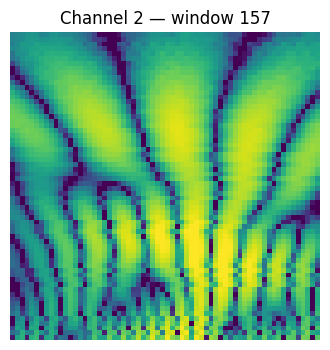

In [ ]:
idx = len(wins) // 2
tile, freqs = cwt_tile(wins[idx], fs, fmin=4, fmax=40, num_freqs=64, log_power=True)
tile_img = resize_tile(tile, out_size=(64, 64))

plt.figure(figsize=(4, 4))
plt.imshow(tile_img, cmap="viridis", aspect="auto")
plt.axis("off")
plt.title(f"{channel_name} — window {idx}")
plt.show()